# FleXgeo2 quickstart analysis

This notebook runs a first FleXgeo2 analysis on `pdb2lj5.pdb`, a 301-model NMR ensemble of human ubiquitin. The goal is to get from a PDB file to curvature/torsion descriptors, summary tables, and the standard overview plot with the smallest useful amount of code.

In [1]:
from pathlib import Path
import sys
import tempfile


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").is_file() and (candidate / "pdb2lj5.pdb").is_file():
            return candidate
    raise FileNotFoundError("Could not find the FleXgeo2 repo root containing pyproject.toml and pdb2lj5.pdb")


REPO_ROOT = find_repo_root()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

try:
    import matplotlib.image as mpimg
    import matplotlib.pyplot as plt
    import melodia_py  # noqa: F401
    import pandas as pd
    from flexgeo2 import AnalysisConfig, FlexGeo2App, OutputConfig
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        f"Missing dependency: {exc.name}. Install the project in your notebook kernel with `pip install -e .` "
        "or, if you use uv, run `uv sync` and select the project environment as the Jupyter kernel."
    ) from exc

PDB_FILE = REPO_ROOT / "pdb2lj5.pdb"
tmpdir = tempfile.TemporaryDirectory(prefix="flexgeo2_quickstart_")
OUTPUT_DIR = Path(tmpdir.name)

print(f"Repo root: {REPO_ROOT}")
print(f"PDB file: {PDB_FILE}")
print(f"Temporary output directory: {OUTPUT_DIR}")

Repo root: /Users/marinho/Projects/flexgeo2
PDB file: /Users/marinho/Projects/flexgeo2/pdb2lj5.pdb
Temporary output directory: /var/folders/b7/m1b34cvd23lg7p7rspz3yqnh0000gp/T/flexgeo2_quickstart_y7c1777x


## Run the analysis

`FlexGeo2App` is the high-level library entrypoint. The config below keeps chain `A`, writes standard outputs to a temporary directory, and limits Melodia to one worker for predictable notebook behavior.

In [2]:
config = AnalysisConfig(
    pdb_file=PDB_FILE,
    chains=["A"],
    n_jobs=1,
    output=OutputConfig(output_dir=OUTPUT_DIR, verbose=False, write_files=True),
)

result = FlexGeo2App().run(config)

## What came back?

The result object keeps the same information that FleXgeo2 writes to disk: raw per-model descriptors, per-residue ensemble summaries, and per-model summaries.

In [3]:
model_count = result.raw_df["model"].nunique()
chain_count = result.raw_df["chain"].nunique()
residue_count = result.raw_df.groupby(["chain", "order"]).ngroups

print(f"Models: {model_count}")
print(f"Chains: {chain_count}")
print(f"Residues: {residue_count}")
print(f"Raw descriptor rows: {len(result.raw_df):,}")

Models: 301
Chains: 1
Residues: 76
Raw descriptor rows: 22,876


In [4]:
result.raw_df.head()

,id,model,code,chain,order,name,curvature,torsion,arc_length,writhing,phi,psi,residue_label
0,0,0,PDB2LJ5,A,1,MET,0.520270,0.020683,8.001034,-0.002049,NaN,128.231608,MET1
1,1,0,PDB2LJ5,A,2,GLN,0.520270,0.020683,7.906316,-0.002049,-85.241797,125.700619,GLN2
2,2,0,PDB2LJ5,A,3,ILE,0.689421,-0.042487,7.760240,-0.002049,-114.165991,153.562788,ILE3
3,3,0,PDB2LJ5,A,4,PHE,0.634875,-0.100278,7.758534,-0.015124,-118.282077,145.835450,PHE4
4,4,0,PDB2LJ5,A,5,VAL,0.824192,-0.094061,7.858813,-0.012377,-112.320944,126.640808,VAL5


`raw_df` has one row per model, chain, and residue. The key descriptor columns are `curvature` and `torsion`.

In [5]:
result.residue_summary_df.head()

,chain,order,name,residue_label,curvature_mean,curvature_std,curvature_min,curvature_max,torsion_mean,torsion_std,torsion_min,torsion_max,models
0,A,1,MET,MET1,0.514353,0.064986,0.325864,0.699961,-0.009660,0.013937,-0.051142,0.036073,301
1,A,2,GLN,GLN2,0.514353,0.064986,0.325864,0.699961,-0.009660,0.013937,-0.051142,0.036073,301
2,A,3,ILE,ILE3,0.583653,0.065199,0.419426,0.815847,-0.085308,0.013672,-0.121378,-0.036480,301
3,A,4,PHE,PHE4,0.616037,0.076530,0.414580,0.939250,-0.120778,0.010640,-0.151191,-0.077521,301
4,A,5,VAL,VAL5,0.834924,0.097212,0.603803,1.123519,-0.103026,0.011403,-0.148288,-0.065921,301


`residue_summary_df` collapses the ensemble by residue, giving mean, standard deviation, minimum, and maximum values for curvature and torsion.

In [6]:
result.overall_model_summary_df.head()

,model,residues,curvature_mean,torsion_mean,curvature_mean_abs_deviation,torsion_mean_abs_deviation
0,0,76,0.405282,-0.156256,0.069587,0.089139
1,1,76,0.446268,-0.124386,0.057198,0.042906
2,2,76,0.428620,-0.138668,0.060762,0.062695
3,3,76,0.439325,-0.156384,0.060879,0.063953
4,4,76,0.423456,-0.129611,0.051847,0.057606


`overall_model_summary_df` summarizes each model and reports mean absolute deviation from the ensemble mean, which is useful for quickly finding conformations that differ most from the ensemble average.

In [7]:
from dataclasses import fields

artifacts = result.outputs
for field in fields(artifacts):
    name = field.name
    path = getattr(artifacts, name)
    if path is not None:
        print(f"{name}: {path}")

raw_csv: /private/var/folders/b7/m1b34cvd23lg7p7rspz3yqnh0000gp/T/flexgeo2_quickstart_y7c1777x/geometry_descriptors.csv
residue_summary_csv: /private/var/folders/b7/m1b34cvd23lg7p7rspz3yqnh0000gp/T/flexgeo2_quickstart_y7c1777x/residue_summary.csv
overall_model_summary_csv: /private/var/folders/b7/m1b34cvd23lg7p7rspz3yqnh0000gp/T/flexgeo2_quickstart_y7c1777x/model_summary_overall.csv
overview_plot: /private/var/folders/b7/m1b34cvd23lg7p7rspz3yqnh0000gp/T/flexgeo2_quickstart_y7c1777x/plots/ensemble_overview.png


## Overview plot

The overview plot shows the ensemble mean curvature and torsion for each residue, with a shaded standard deviation band.

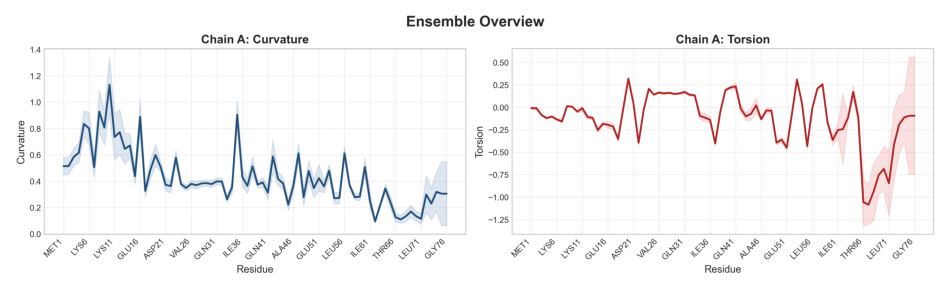

In [8]:
assert artifacts.overview_plot is not None and artifacts.overview_plot.is_file()
img = mpimg.imread(artifacts.overview_plot)
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.show()